In [1]:
import pandas as pd
import numpy as np

file1 = "wandb_export_2026-04-16T20_16_18.696+08_00.csv"
df1 = pd.read_csv(file1)
df1['win_rate'] = df1["inrl-temporal-6 - eval/black_vs_baseline"]
df1 = df1[['Step', 'win_rate']]
file2 = "wandb_export_2026-04-16T20_19_12.133+08_00.csv"
df2 = pd.read_csv(file2)
df2['win_rate'] = df2["inrl-temporal-6 - eval/black_vs_white_pool1"]
df2 = df2[['Step', 'win_rate']]
file3 = "wandb_export_2026-04-16T20_20_17.168+08_00.csv"
df3 = pd.read_csv(file3)
df3['win_rate'] = df3["inrl-temporal-6 - eval/black_vs_white_pool1"]
df3 = df3[['Step', 'win_rate']]
file4 = "wandb_export_2026-04-16T20_20_49.384+08_00.csv"
df4 = pd.read_csv(file4)
df4['win_rate'] = df4["inrl-temporal-6 - eval/black_vs_white_pool1"]
df4 = df4[['Step', 'win_rate']]
file5 = "wandb_export_2026-04-16T20_21_30.658+08_00.csv"
df5 = pd.read_csv(file5)
df5['win_rate'] = df5["inrl-temporal-6 - eval/black_vs_white_pool1"]
df5 = df5[['Step', 'win_rate']]

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)
df['Step'] = df.index*5
df = df[['Step', 'win_rate']]
df.head()

,Step,win_rate
0,0,0.0
1,5,0.0
2,10,0.0
3,15,0.0
4,20,0.0


In [7]:
file1_ = "wandb_export_2026-04-16T20_31_10.179+08_00.csv"
df1_ = pd.read_csv(file1_)
df1_['win_rate'] = df1_["inrl - no - pretrained - action - pruning - v1 - eval/black_vs_baseline"]
file2_ = "wandb_export_2026-04-16T20_31_52.783+08_00.csv"
df2_ = pd.read_csv(file2_)
df2_['win_rate'] = df2_["inrl - no - pretrained - action - pruning - v1 - eval/black_vs_baseline"]
file3_ = "wandb_export_2026-04-16T20_32_23.948+08_00.csv"
df3_ = pd.read_csv(file3_)
df3_['win_rate'] = df3_["inrl - no - pretrained - action - pruning - v1 - eval/black_vs_baseline"]
file4_ = "wandb_export_2026-04-16T20_34_43.622+08_00.csv"
df4_ = pd.read_csv(file4_)
df4_['win_rate'] = df4_["inrl-balance-ema-v1 - eval/black_vs_baseline"]
file5_ = "wandb_export_2026-04-16T20_35_15.306+08_00.csv"
df5_ = pd.read_csv(file5_)
df5_['win_rate'] = df5_["inrl-balance-ema-v1 - eval/black_vs_baseline"]
file6_ = "wandb_export_2026-04-17T02_26_14.922+08_00.csv"
df6_ = pd.read_csv(file6_)
df6_['win_rate'] = df5_["inrl-balance-ema-v1 - eval/black_vs_baseline"]
file7_ = "wandb_export_2026-04-17T02_30_03.148+08_00.csv"
df7_ = pd.read_csv(file7_)
df7_['win_rate'] = df5_["inrl-balance-ema-v1 - eval/black_vs_baseline"]
file8_ = "wandb_export_2026-04-17T02_31_03.380+08_00.csv"
df8_ = pd.read_csv(file8_)
df8_['win_rate'] = df5_["inrl-balance-ema-v1 - eval/black_vs_baseline"]
df_ = pd.concat([df1_, df2_, df3_, df4_, df5_,df6_,df7_,df8_], ignore_index=True)
df_['Step'] = df_.index*5
df_ = df_[['Step', 'win_rate']]
df_.head()

,Step,win_rate
0,0,0.0
1,5,0.0
2,10,0.0
3,15,0.0
4,20,0.0


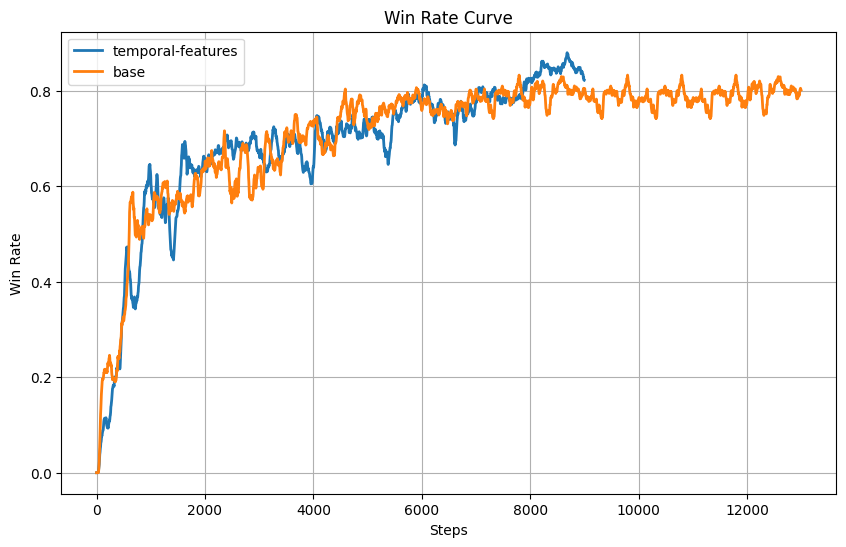

In [11]:
import matplotlib.pyplot as plt

# 先确保是数值，防止有字符串或空值
df['win_rate'] = pd.to_numeric(df['win_rate'], errors='coerce')
df_['win_rate'] = pd.to_numeric(df_['win_rate'], errors='coerce')
# 去掉空值
plot_df = df.dropna(subset=['win_rate']).copy()
plot_df_ = df_.dropna(subset=['win_rate']).copy()

# 方式1：滑动平均
plot_df['win_rate_smooth_roll'] = plot_df['win_rate'].rolling(window=5, min_periods=1).mean()
plot_df_['win_rate_smooth_roll'] = plot_df_['win_rate'].rolling(window=5, min_periods=1).mean()

# 方式2：EMA平滑（更推荐）
plot_df['win_rate_smooth_ema'] = plot_df['win_rate'].ewm(span=10, adjust=False).mean()
plot_df_['win_rate_smooth_ema'] = plot_df_['win_rate'].ewm(span=10, adjust=False).mean()

plt.figure(figsize=(10, 6))

# 平滑曲线（推荐画 EMA）
plt.plot(plot_df['Step'], plot_df['win_rate_smooth_ema'], label='temporal-features', linewidth=2)
plt.plot(plot_df_['Step'], plot_df_['win_rate_smooth_ema'], label='base', linewidth=2)

# 如果你也想看 rolling mean，把下面这行取消注释
# plt.plot(plot_df['Step'], plot_df['win_rate_smooth_roll'], label='Smoothed trend (Rolling Mean)', linewidth=2)

plt.xlabel('Steps')
plt.ylabel('Win Rate')
plt.title('Win Rate Curve')
plt.legend()
plt.grid(True)
plt.show()